# HSEmotion Training on FERPlus

This notebook fine-tunes **HSEmotion** (AffectNet-pretrained EfficientNet-B0)
for facial emotion recognition using the FERPlus dataset. It is designed to run
with a Google Colab GPU kernel via the VS Code Colab integration.

HSEmotion (Savchenko, 2022) differs from the standard EfficientNet-B0 model
already in this repository: instead of ImageNet pretraining, it uses weights
trained on AffectNet (a large-scale facial expression dataset). This provides
domain-specific feature representations that are more relevant for emotion
recognition.

**Workflow:**
1. **Phase 1 -- Base run:** Freeze the AffectNet-pretrained backbone entirely,
   train only a simple classifier head, and evaluate.
2. **Phase 2 -- Optimized run:** Unfreeze the last 2 feature blocks and use
   a 2-layer classifier head (matching `models/hsemotion_model.py`), with
   differential learning rates and a LR scheduler.

Phase 2 is included because frozen-backbone baselines may still show room
for improvement: while AffectNet pretraining is closer to the target domain
than ImageNet, the FERPlus label set and image distribution differ from
AffectNet, so partial fine-tuning typically helps.

**Important:** Make sure you select a GPU runtime
(Runtime > Change runtime type > T4 GPU).

**Reference:**
- Savchenko, A.V. (2022). HSEmotion: High-Speed face Emotion recognition
  library. SoftwareX, 18, 101065.

## 0. Google Drive Mount (Optional)

Mount Google Drive so that output artifacts (checkpoints, plots, metrics)
can be copied to a Drive folder for easy download after Colab disconnects.
Skip this cell if you do not need Drive access.

In [1]:
# Set SAVE_TO_DRIVE = True to copy outputs to Google Drive
SAVE_TO_DRIVE = True
DRIVE_OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "emotion_project/results/hsemotion"
)

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    import os
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print(f"Drive output dir: {DRIVE_OUTPUT_DIR}")
else:
    print("Google Drive mount skipped.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive output dir: /content/drive/MyDrive/emotion_project/results/hsemotion


## 1. Environment Setup

In [2]:
# GPU availability check
!nvidia-smi

import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[WARNING] No GPU detected. Select a GPU runtime.")

Sun Mar 15 18:05:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             33W /   70W |    1043MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Clone the repository from GitHub
import os

REPO_URL = (
    "https://github.com/aysenurhepguven0/"
    "adaptive-emotion-aware-virtual-interaction-system.git"
)
REPO_DIR = (
    "/content/"
    "adaptive-emotion-aware-virtual-interaction-system"
)

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repository already exists at {REPO_DIR}")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Repository already exists at /content/adaptive-emotion-aware-virtual-interaction-system
Working directory: /content/adaptive-emotion-aware-virtual-interaction-system


In [4]:
# Install project dependencies
# timm: backbone model library required by HSEmotion
# hsemotion: provides AffectNet-pretrained weights
%pip install -q -r requirements.txt
%pip install -q kagglehub timm hsemotion

  Preparing metadata (setup.py) ... done


## 2. Configuration and Imports

In [5]:
import sys
import json
import time
import shutil
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Ensure project root is on the import path
PROJECT_ROOT = Path(REPO_DIR).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"timm version: {timm.__version__}")
print("Imports complete.")

Project root: /content/adaptive-emotion-aware-virtual-interaction-system
timm version: 1.0.25
Imports complete.


In [6]:
# --- Paths ---
DATASET_PATH = PROJECT_ROOT / "data" / "ferplus"
OUTPUT_DIR = PROJECT_ROOT / "results" / "hsemotion"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Speed up convolutions for fixed input size
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# --- Class filter ---
# FERPlus has 8 classes but Contempt, Disgust, and Fear have
# too few test samples and hurt macro-weighted F1. Use 5 classes.
TARGET_CLASSES = ["angry", "happy", "neutral", "sad", "suprise"]

# --- Hyperparameters (shared / Phase 2) ---
NUM_EPOCHS = 30 if torch.cuda.is_available() else 10
BATCH_SIZE = 128 if torch.cuda.is_available() else 32
INPUT_SIZE = 224  # EfficientNet-B0 standard resolution
EARLY_STOPPING_PATIENCE = 10

# --- Phase 1 hyperparameters (frozen backbone) ---
PHASE1_LR = 1e-3
PHASE1_WEIGHT_DECAY = 1e-4
PHASE1_DROPOUT = 0.4
PHASE1_EPOCHS = 10
PHASE1_PATIENCE = 5

# --- Phase 2 hyperparameters (partial fine-tuning) ---
PHASE2_BACKBONE_LR = 1e-5
PHASE2_CLASSIFIER_LR = 1e-4
PHASE2_WEIGHT_DECAY = 1e-4
PHASE2_UNFREEZE_LAST_N = 2

print(f"Device:     {DEVICE}")
print(f"P1 epochs:  {PHASE1_EPOCHS} (patience {PHASE1_PATIENCE})")
print(f"P2 epochs:  {NUM_EPOCHS} (patience {EARLY_STOPPING_PATIENCE})")
print(f"Batch size: {BATCH_SIZE}")
print(f"Input size: {INPUT_SIZE}x{INPUT_SIZE}")
print(f"Classes:    {TARGET_CLASSES}")
print(f"Dataset:    {DATASET_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Device:     cuda
P1 epochs:  10 (patience 5)
P2 epochs:  30 (patience 10)
Batch size: 128
Input size: 224x224
Classes:    ['angry', 'happy', 'neutral', 'sad', 'suprise']
Dataset:    /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus
Output dir: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion


## 3. Dataset Preparation

In [7]:
# Download FERPlus from Kaggle if not already present
import kagglehub

splits_exist = (
    (DATASET_PATH / "train").exists()
    and (DATASET_PATH / "test").exists()
)

if not splits_exist:
    print("Downloading FERPlus dataset from Kaggle...")
    ferplus_download = kagglehub.dataset_download(
        "arnabkumarroy02/ferplus"
    )
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    !cp -r {ferplus_download}/* {DATASET_PATH}/
    print(f"Dataset saved to: {DATASET_PATH}")
else:
    print(f"Dataset already exists at: {DATASET_PATH}")

Dataset already exists at: /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus


In [8]:
# Verify dataset structure
print("FERPlus dataset structure:")
for split in ["train", "validation", "test"]:
    split_path = DATASET_PATH / split
    if split_path.exists():
        classes = sorted(
            d.name for d in split_path.iterdir()
            if d.is_dir()
        )
        total = sum(
            len(list((split_path / c).iterdir()))
            for c in classes
        )
        print(
            f"  {split:12s}: {total:>6,} images, "
            f"{len(classes)} classes"
        )
    else:
        print(f"  {split:12s}: NOT FOUND")

FERPlus dataset structure:
  train       : 66,379 images, 8 classes
  validation  :  8,341 images, 8 classes
  test        :  3,573 images, 8 classes


In [9]:
# Build transforms and create DataLoaders
# FERPlus images are 48x48 grayscale; resize to 224x224 and
# convert to 3-channel for EfficientNet-B0 backbone.
train_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1, contrast=0.1, saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def filter_classes(dataset, target_classes):
    """Keep only samples belonging to target_classes
    and remap labels to 0..len(target_classes)-1."""
    keep_indices = {
        dataset.class_to_idx[c] for c in target_classes
        if c in dataset.class_to_idx
    }
    idx_map = {
        old: new
        for new, old in enumerate(sorted(keep_indices))
    }
    dataset.samples = [
        (path, idx_map[label])
        for path, label in dataset.samples
        if label in idx_map
    ]
    dataset.targets = [s[1] for s in dataset.samples]
    dataset.classes = [
        c for c in dataset.classes
        if dataset.class_to_idx.get(c) in keep_indices
    ]
    dataset.class_to_idx = {
        c: i for i, c in enumerate(dataset.classes)
    }
    return dataset


train_dataset = datasets.ImageFolder(
    DATASET_PATH / "train", transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    DATASET_PATH / "validation", transform=eval_transforms
)
test_dataset = datasets.ImageFolder(
    DATASET_PATH / "test", transform=eval_transforms
)

# Filter to 5 target classes
filter_classes(train_dataset, TARGET_CLASSES)
filter_classes(val_dataset, TARGET_CLASSES)
filter_classes(test_dataset, TARGET_CLASSES)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

_loader_kwargs = dict(
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, **_loader_kwargs,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, **_loader_kwargs,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, **_loader_kwargs,
)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(
    f"Train: {len(train_dataset):,} | "
    f"Val: {len(val_dataset):,} | "
    f"Test: {len(test_dataset):,}"
)

Classes (5): ['angry', 'happy', 'neutral', 'sad', 'suprise']
Train: 42,379 | Val: 5,341 | Test: 3,424


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 4. Helper Functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    """Train for one epoch. Returns (loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    use_amp = scaler is not None and device.type == "cuda"
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * labels.size(0)
        correct += (
            (outputs.argmax(dim=1) == labels).sum().item()
        )
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate on a data loader. Returns (loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    use_amp = device.type == "cuda"
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            correct += (
                (outputs.argmax(dim=1) == labels)
                .sum().item()
            )
            total += labels.size(0)
    return running_loss / total, correct / total


def run_training_loop(
    model, train_loader, val_loader, criterion,
    optimizer, num_epochs, patience, checkpoint_path,
    device, scheduler=None, scaler=None,
):
    """Full training loop with early stopping.

    Returns:
        history (dict): train/val loss and accuracy per epoch.
        best_val_acc (float): Best validation accuracy achieved.
    """
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
    }
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer,
            device, scaler=scaler,
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )
        elapsed = time.time() - start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if scheduler is not None:
            scheduler.step(val_loss)

        marker = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                model.state_dict(), checkpoint_path
            )
            patience_counter = 0
            marker = " [BEST]"
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:>2}/{num_epochs} "
            f"({elapsed:.0f}s) | "
            f"Train {train_loss:.4f} / {train_acc:.2%} | "
            f"Val {val_loss:.4f} / {val_acc:.2%}{marker}"
        )

        if patience_counter >= patience:
            print(
                f"Early stopping at epoch {epoch} "
                f"(no improvement for {patience} epochs)"
            )
            break

    return history, best_val_acc


def predict_test_set(model, loader, device):
    """Run inference on the test set.

    Returns:
        y_true (list): Ground truth labels.
        y_pred (list): Predicted labels.
    """
    model.eval()
    y_true, y_pred = [], []
    use_amp = device.type == "cuda"
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(images)
            preds = outputs.argmax(dim=1)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    return y_true, y_pred


def plot_training_history(history, title, save_path):
    """Plot loss and accuracy curves and save to disk."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(
        1, len(history["train_loss"]) + 1
    )

    axes[0].plot(
        epochs_range, history["train_loss"], label="Train"
    )
    axes[0].plot(
        epochs_range, history["val_loss"],
        label="Validation",
    )
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(
        epochs_range, history["train_acc"], label="Train"
    )
    axes[1].plot(
        epochs_range, history["val_acc"],
        label="Validation",
    )
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


def plot_confusion_matrices(
    y_true, y_pred, class_names, title_prefix, save_dir
):
    """Plot and save normalized and count confusion matrices."""
    cm = confusion_matrix(
        y_true, y_pred, normalize="true"
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=class_names
    )
    disp.plot(
        ax=ax, cmap="Blues",
        values_format=".2f", colorbar=True,
    )
    ax.set_title(f"{title_prefix} Confusion Matrix")
    fig.tight_layout()
    norm_path = save_dir / "confusion_matrix.png"
    fig.savefig(norm_path, dpi=150)
    plt.show()

    cm_counts = confusion_matrix(y_true, y_pred)
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    disp2 = ConfusionMatrixDisplay(
        confusion_matrix=cm_counts,
        display_labels=class_names,
    )
    disp2.plot(
        ax=ax2, cmap="Blues",
        values_format="d", colorbar=True,
    )
    ax2.set_title(
        f"{title_prefix} Confusion Matrix - Counts"
    )
    fig2.tight_layout()
    counts_path = save_dir / "confusion_matrix_counts.png"
    fig2.savefig(counts_path, dpi=150)
    plt.show()

    print(f"Saved: {norm_path}")
    print(f"Saved: {counts_path}")


def save_outputs(
    history, y_true, y_pred, class_names,
    model_name, best_val_acc, extra_info, save_dir,
):
    """Save training history and evaluation summary as JSON."""
    history_path = save_dir / "training_history.json"
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    test_acc = sum(
        t == p for t, p in zip(y_true, y_pred)
    ) / len(y_true)
    report_dict = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
    )
    eval_summary = {
        "model": model_name,
        "dataset": "ferplus",
        "num_classes": len(class_names),
        "class_names": list(class_names),
        "input_size": INPUT_SIZE,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
        "classification_report": report_dict,
    }
    eval_summary.update(extra_info)
    eval_path = save_dir / "evaluation_summary.json"
    with open(eval_path, "w") as f:
        json.dump(eval_summary, f, indent=2)

    print(f"All outputs saved to: {save_dir}")
    print("-" * 50)
    for p in sorted(save_dir.iterdir()):
        size_kb = p.stat().st_size / 1024
        print(f"  {p.name:40s} {size_kb:>8.1f} KB")

    return test_acc


def copy_to_drive(src_dir, drive_dir):
    """Copy all files from src_dir to drive_dir."""
    if not SAVE_TO_DRIVE:
        print("Drive save skipped (SAVE_TO_DRIVE=False).")
        return
    drive_path = Path(drive_dir)
    drive_path.mkdir(parents=True, exist_ok=True)
    for f in sorted(Path(src_dir).iterdir()):
        if f.is_file():
            shutil.copy2(f, drive_path / f.name)
        elif f.is_dir():
            sub_dest = drive_path / f.name
            sub_dest.mkdir(parents=True, exist_ok=True)
            for sf in sorted(f.iterdir()):
                if sf.is_file():
                    shutil.copy2(sf, sub_dest / sf.name)
    print(f"Copied outputs to Drive: {drive_path}")

## 4b. Load AffectNet-Pretrained Backbone

Load the AffectNet-pretrained EfficientNet-B0 weights from the
`hsemotion` package. This backbone will be reused by both Phase 1
and Phase 2. If the package is not available, the notebook falls
back to ImageNet pretrained weights from `timm`.

In [11]:
# Attempt to load AffectNet-pretrained backbone
AFFECTNET_LOADED = False

try:
    from hsemotion.facial_emotions import (
        HSEmotionRecognizer,
    )
    _recognizer = HSEmotionRecognizer(
        model_name='enet_b0_8_best_vgaf',
        device='cpu'
    )
    _affectnet_backbone = _recognizer.model
    AFFECTNET_LOADED = True
    print(
        "AffectNet-pretrained backbone loaded "
        "via hsemotion package."
    )
    print(
        f"  Backbone type: "
        f"{type(_affectnet_backbone).__name__}"
    )
    print(
        f"  Feature dim:   "
        f"{_affectnet_backbone.num_features}"
    )
except ImportError:
    print(
        "[WARNING] hsemotion package not available. "
        "Using ImageNet pretrained weights."
    )
except Exception as e:
    print(
        f"[WARNING] Could not load AffectNet weights: {e}"
    )
    print("Falling back to ImageNet pretrained weights.")


def create_affectnet_backbone():
    """Create a fresh copy of the AffectNet-pretrained backbone.

    Returns a new model instance each time so that Phase 1 and
    Phase 2 start from the same pretrained weights.
    """
    if AFFECTNET_LOADED:
        import copy
        return copy.deepcopy(_affectnet_backbone)
    else:
        return timm.create_model(
            'efficientnet_b0', pretrained=True
        )

[WARNING] Could not load AffectNet weights: HTTP Error 429: Too Many Requests
Falling back to ImageNet pretrained weights.


---

## Phase 1 -- Base Run (Frozen Backbone)

Freeze the entire AffectNet-pretrained backbone and train only
a simple classifier head. This measures how well the AffectNet
features transfer to FERPlus without any adaptation.

Because the backbone was pretrained on emotion data (AffectNet)
rather than ImageNet, Phase 1 is expected to perform better than
the frozen-backbone baselines of the EfficientNet-B0 and ResNet-18
notebooks, which started from ImageNet features.

### 5a. Model Initialization (Phase 1)

In [12]:
# Load backbone and freeze entirely.
# Train only a simple linear classifier head.
model_p1 = create_affectnet_backbone()

# Freeze all backbone parameters
for param in model_p1.parameters():
    param.requires_grad = False

# Replace classifier with simple head: Dropout -> Linear
in_features = model_p1.num_features  # 1280
model_p1.classifier = nn.Sequential(
    nn.Dropout(p=PHASE1_DROPOUT, inplace=True),
    nn.Linear(in_features, NUM_CLASSES),
)

# Disable timm's built-in dropout (our head has its own)
model_p1.drop_rate = 0.0

model_p1 = model_p1.to(DEVICE)

total_params = sum(p.numel() for p in model_p1.parameters())
trainable_params = sum(
    p.numel() for p in model_p1.parameters()
    if p.requires_grad
)

pretraining = "AffectNet" if AFFECTNET_LOADED else "ImageNet"
print(f"Phase 1: HSEmotion ({pretraining}, frozen backbone)")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(
    f"  Frozen parameters:    "
    f"{total_params - trainable_params:,}"
)
print(f"  Number of classes:    {NUM_CLASSES}")
print(f"  Input size:           {INPUT_SIZE}x{INPUT_SIZE}x3")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Phase 1: HSEmotion (ImageNet, frozen backbone)
  Total parameters:     4,013,953
  Trainable parameters: 6,405
  Frozen parameters:    4,007,548
  Number of classes:    5
  Input size:           224x224x3


### 5b. Training (Phase 1)

In [13]:
# Output directory for Phase 1
P1_DIR = OUTPUT_DIR / "phase1_frozen"
P1_DIR.mkdir(parents=True, exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer_p1 = torch.optim.Adam(
    model_p1.parameters(),
    lr=PHASE1_LR,
    weight_decay=PHASE1_WEIGHT_DECAY,
)

# Mixed-precision scaler
scaler_p1 = (
    torch.amp.GradScaler("cuda")
    if torch.cuda.is_available() else None
)

print("Phase 1: Training HSEmotion (frozen backbone)")
print(
    f"  Device: {DEVICE} | Batch: {BATCH_SIZE} | "
    f"LR: {PHASE1_LR} | AMP: {scaler_p1 is not None}"
)
print("=" * 70)

history_p1, best_val_acc_p1 = run_training_loop(
    model=model_p1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_p1,
    num_epochs=PHASE1_EPOCHS,
    patience=PHASE1_PATIENCE,
    checkpoint_path=P1_DIR / "best_model.pth",
    device=DEVICE,
    scaler=scaler_p1,
)

print("=" * 70)
print(f"Phase 1 best val accuracy: {best_val_acc_p1:.2%}")

Phase 1: Training HSEmotion (frozen backbone)
  Device: cuda | Batch: 128 | LR: 0.001 | AMP: True


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch  1/10 (238s) | Train 1.2444 / 49.36% | Val 1.1866 / 54.05% [BEST]
Epoch  2/10 (212s) | Train 1.1530 / 53.58% | Val 1.1444 / 55.25% [BEST]
Epoch  3/10 (213s) | Train 1.1360 / 54.46% | Val 1.1407 / 55.96% [BEST]
Epoch  4/10 (214s) | Train 1.1386 / 54.42% | Val 1.1269 / 56.39% [BEST]
Epoch  5/10 (213s) | Train 1.1374 / 54.39% | Val 1.1316 / 55.65%
Epoch  6/10 (213s) | Train 1.1345 / 54.55% | Val 1.1372 / 55.65%
Epoch  7/10 (212s) | Train 1.1381 / 54.24% | Val 1.1054 / 57.37% [BEST]
Epoch  8/10 (211s) | Train 1.1344 / 54.44% | Val 1.1115 / 56.71%
Epoch  9/10 (212s) | Train 1.1340 / 54.20% | Val 1.1224 / 56.73%
Epoch 10/10 (213s) | Train 1.1334 / 54.59% | Val 1.1163 / 56.30%
Phase 1 best val accuracy: 57.37%


### 5c. Evaluation (Phase 1)

In [14]:
# Load best Phase 1 checkpoint and evaluate
model_p1.load_state_dict(
    torch.load(
        P1_DIR / "best_model.pth", map_location=DEVICE
    )
)

y_true_p1, y_pred_p1 = predict_test_set(
    model_p1, test_loader, DEVICE
)
test_acc_p1 = sum(
    t == p for t, p in zip(y_true_p1, y_pred_p1)
) / len(y_true_p1)

print(f"Phase 1 Test Accuracy: {test_acc_p1:.2%}")
print()
print(classification_report(
    y_true_p1, y_pred_p1, target_names=CLASS_NAMES
))

Phase 1 Test Accuracy: 55.78%

              precision    recall  f1-score   support

       angry       0.39      0.31      0.34       322
       happy       0.61      0.57      0.59       929
     neutral       0.54      0.78      0.64      1274
         sad       0.48      0.11      0.17       449
     suprise       0.66      0.53      0.59       450

    accuracy                           0.56      3424
   macro avg       0.54      0.46      0.47      3424
weighted avg       0.55      0.56      0.53      3424



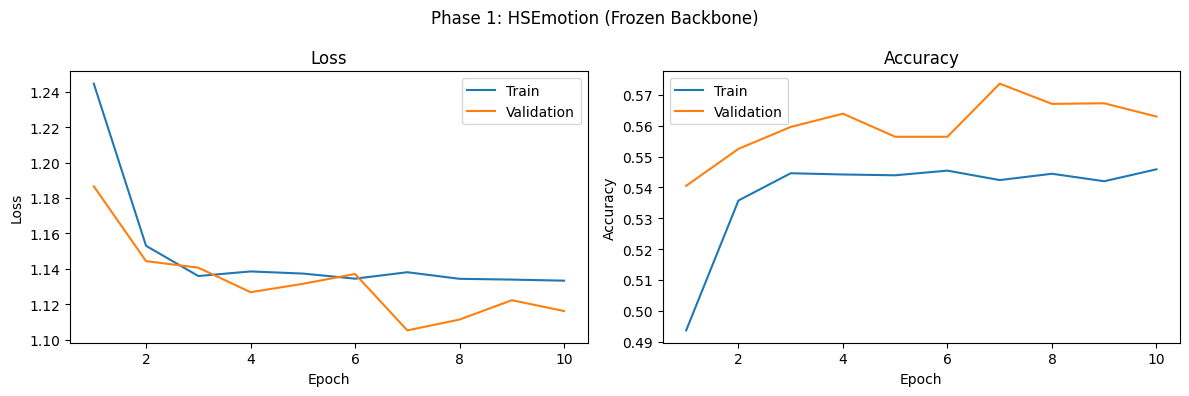

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/phase1_frozen/training_history.png


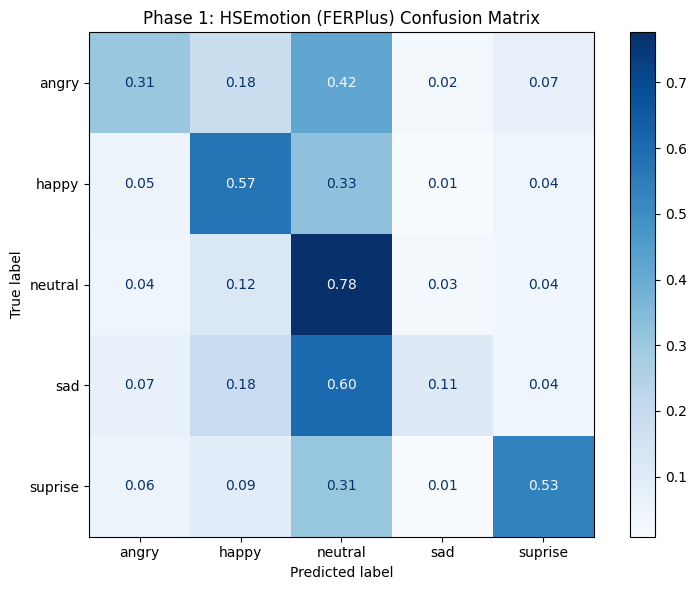

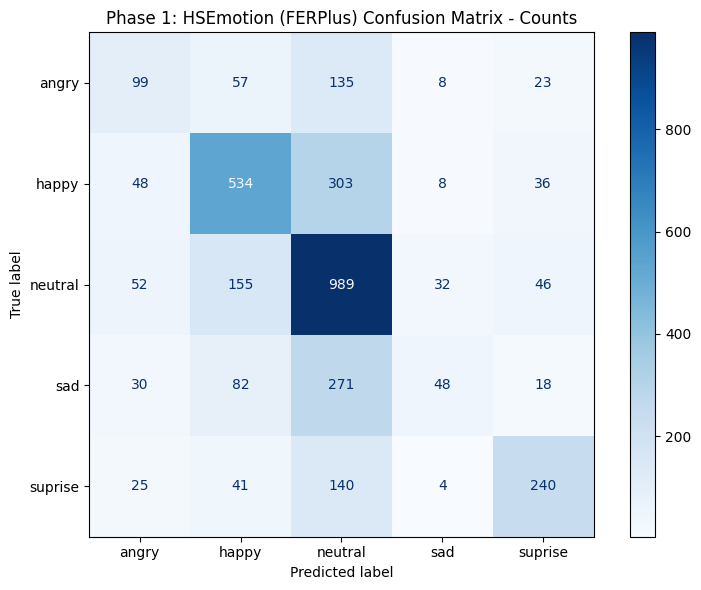

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/phase1_frozen/confusion_matrix.png
Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/phase1_frozen/confusion_matrix_counts.png


In [15]:
# Phase 1 training curves
plot_training_history(
    history_p1,
    "Phase 1: HSEmotion (Frozen Backbone)",
    P1_DIR / "training_history.png",
)

# Phase 1 confusion matrices
plot_confusion_matrices(
    y_true_p1, y_pred_p1, CLASS_NAMES,
    "Phase 1: HSEmotion (FERPlus)", P1_DIR,
)

In [16]:
# Save Phase 1 outputs
save_outputs(
    history=history_p1,
    y_true=y_true_p1,
    y_pred=y_pred_p1,
    class_names=CLASS_NAMES,
    model_name="hsemotion_phase1_frozen",
    best_val_acc=best_val_acc_p1,
    extra_info={
        "phase": "phase1_frozen_backbone",
        "pretraining": "AffectNet" if AFFECTNET_LOADED else "ImageNet",
        "dropout": PHASE1_DROPOUT,
        "learning_rate": PHASE1_LR,
        "trainable_params": sum(
            p.numel() for p in model_p1.parameters()
            if p.requires_grad
        ),
    },
    save_dir=P1_DIR,
)

All outputs saved to: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/phase1_frozen
--------------------------------------------------
  best_model.pth                            15968.3 KB
  confusion_matrix.png                         69.5 KB
  confusion_matrix_counts.png                  63.6 KB
  evaluation_summary.json                       1.6 KB
  training_history.json                         1.0 KB
  training_history.png                         80.0 KB


0.5578271028037384

### 5d. Phase 1 Analysis

Check whether the Phase 1 results justify running Phase 2.
Criteria for triggering optimization:
- Test accuracy below 60% (poor for a 5-class problem)
- Training accuracy close to or below validation accuracy
  (indicates underfitting, not overfitting)
- Macro F1 below 0.55

In [17]:
# Decision logic for Phase 2
report_dict_p1 = classification_report(
    y_true_p1, y_pred_p1,
    target_names=CLASS_NAMES,
    output_dict=True,
)
macro_f1_p1 = report_dict_p1["macro avg"]["f1-score"]
final_train_acc = history_p1["train_acc"][-1]

print("Phase 1 Results Summary:")
print(f"  Test accuracy:     {test_acc_p1:.2%}")
print(f"  Macro F1:          {macro_f1_p1:.4f}")
print(f"  Final train acc:   {final_train_acc:.2%}")
print(f"  Best val acc:      {best_val_acc_p1:.2%}")
print()

is_underfitting = (
    final_train_acc <= best_val_acc_p1 + 0.02
)
is_low_accuracy = test_acc_p1 < 0.60
is_low_f1 = macro_f1_p1 < 0.55

run_phase2 = (
    is_underfitting or is_low_accuracy or is_low_f1
)

if run_phase2:
    reasons = []
    if is_underfitting:
        reasons.append(
            f"underfitting (train {final_train_acc:.2%} "
            f"<= val {best_val_acc_p1:.2%})"
        )
    if is_low_accuracy:
        reasons.append(
            f"low test accuracy ({test_acc_p1:.2%} < 60%)"
        )
    if is_low_f1:
        reasons.append(
            f"low macro F1 ({macro_f1_p1:.4f} < 0.55)"
        )
    print("DECISION: Phase 2 optimization IS justified.")
    print(f"  Reasons: {'; '.join(reasons)}")
    print()
    print(
        "  Phase 2 will unfreeze the last 2 feature "
        "blocks and use a 2-layer classifier head, "
        "matching the architecture in "
        "models/hsemotion_model.py."
    )
else:
    print(
        "DECISION: Phase 1 results are acceptable. "
        "Phase 2 optimization is NOT needed."
    )
    print(
        "  Skip the Phase 2 cells below and proceed "
        "directly to the final summary."
    )

Phase 1 Results Summary:
  Test accuracy:     55.78%
  Macro F1:          0.4677
  Final train acc:   54.59%
  Best val acc:      57.37%

DECISION: Phase 2 optimization IS justified.
  Reasons: underfitting (train 54.59% <= val 57.37%); low test accuracy (55.78% < 60%); low macro F1 (0.4677 < 0.55)

  Phase 2 will unfreeze the last 2 feature blocks and use a 2-layer classifier head, matching the architecture in models/hsemotion_model.py.


---

## Phase 2 -- Optimized Run (Partial Fine-Tuning)

This phase uses the `HSEmotion` architecture defined inline
(mirroring `models/hsemotion_model.py` exactly):
- AffectNet-pretrained backbone with last 2 feature blocks unfrozen
- 2-layer classifier head (1280 -> 256 -> NUM_CLASSES)
- Differential learning rate: lower for backbone, higher for classifier
- ReduceLROnPlateau scheduler to escape loss plateaus

### 6a. Model Initialization (Phase 2)

In [18]:
if not run_phase2:
    print("Phase 2 skipped (Phase 1 results acceptable).")
else:
    # Define HSEmotion inline to keep the notebook
    # self-contained. This mirrors models/hsemotion_model.py
    # exactly so outputs are identical to the project module.
    class HSEmotion(nn.Module):
        """HSEmotion for emotion recognition.

        Architecture matches models/hsemotion_model.py:
          - EfficientNet-B0 backbone (AffectNet or ImageNet)
          - Optional grayscale->RGB adapter (in_channels=1)
          - Custom 2-layer classifier: 1280 -> Dropout -> 256
            -> ReLU -> Dropout -> num_classes
          - Backbone frozen except last unfreeze_last_n
            feature blocks
        """

        def __init__(
            self, num_classes=5, in_channels=3,
            freeze_backbone=True, unfreeze_last_n=2,
        ):
            super().__init__()
            self.in_channels = in_channels

            if in_channels == 1:
                self.channel_adapter = nn.Sequential(
                    nn.Conv2d(
                        1, 3, kernel_size=1, bias=False
                    ),
                    nn.BatchNorm2d(3),
                )
            else:
                self.channel_adapter = None

            # Load AffectNet-pretrained backbone
            self.backbone = create_affectnet_backbone()

            in_features = self.backbone.num_features
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(p=0.4),
                nn.Linear(in_features, 256),
                nn.ReLU(),
                nn.Dropout(p=0.3),
                nn.Linear(256, num_classes),
            )
            self.backbone.drop_rate = 0.0

            if freeze_backbone:
                self._freeze_backbone(unfreeze_last_n)

        def _freeze_backbone(self, unfreeze_last_n=2):
            # Freeze stem
            for param in self.backbone.conv_stem.parameters():
                param.requires_grad = False
            for param in self.backbone.bn1.parameters():
                param.requires_grad = False

            # Freeze all feature blocks
            for block in self.backbone.blocks:
                for param in block.parameters():
                    param.requires_grad = False

            # Unfreeze last N blocks
            total_blocks = len(self.backbone.blocks)
            for i in range(
                max(0, total_blocks - unfreeze_last_n),
                total_blocks,
            ):
                for param in (
                    self.backbone.blocks[i].parameters()
                ):
                    param.requires_grad = True

            # Head conv and BN are always trainable
            if hasattr(self.backbone, 'conv_head'):
                for param in (
                    self.backbone.conv_head.parameters()
                ):
                    param.requires_grad = True
            if hasattr(self.backbone, 'bn2'):
                for param in (
                    self.backbone.bn2.parameters()
                ):
                    param.requires_grad = True

            # Classifier always trainable
            for param in (
                self.backbone.classifier.parameters()
            ):
                param.requires_grad = True

        def forward(self, x):
            if self.channel_adapter is not None:
                x = self.channel_adapter(x)
            return self.backbone(x)

    model_p2 = HSEmotion(
        num_classes=NUM_CLASSES,
        in_channels=3,
        freeze_backbone=True,
        unfreeze_last_n=PHASE2_UNFREEZE_LAST_N,
    )
    model_p2 = model_p2.to(DEVICE)

    total_params = sum(
        p.numel() for p in model_p2.parameters()
    )
    trainable_params = sum(
        p.numel() for p in model_p2.parameters()
        if p.requires_grad
    )

    pretraining = (
        "AffectNet" if AFFECTNET_LOADED else "ImageNet"
    )
    print(
        f"Phase 2: HSEmotion "
        f"({pretraining}, partial fine-tuning)"
    )
    print(f"  Total parameters:     {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(
        f"  Frozen parameters:    "
        f"{total_params - trainable_params:,}"
    )
    print(
        f"  Unfrozen blocks:      "
        f"last {PHASE2_UNFREEZE_LAST_N}"
    )
    print(
        f"  Classifier head:      "
        f"1280 -> 256 -> {NUM_CLASSES}"
    )
    print(
        f"  Input size:           "
        f"{INPUT_SIZE}x{INPUT_SIZE}x3"
    )

Phase 2: HSEmotion (ImageNet, partial fine-tuning)
  Total parameters:     4,336,769
  Trainable parameters: 3,484,961
  Frozen parameters:    851,808
  Unfrozen blocks:      last 2
  Classifier head:      1280 -> 256 -> 5
  Input size:           224x224x3


### 6b. Training (Phase 2)

In [19]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    P2_DIR = OUTPUT_DIR / "phase2_finetuned"
    P2_DIR.mkdir(parents=True, exist_ok=True)

    # Collect unfrozen backbone params
    backbone_params = [
        p for n, p in model_p2.backbone.named_parameters()
        if p.requires_grad
        and not n.startswith("classifier.")
    ]
    classifier_params = list(
        model_p2.backbone.classifier.parameters()
    )

    optimizer_p2 = torch.optim.Adam([
        {
            "params": backbone_params,
            "lr": PHASE2_BACKBONE_LR,
        },
        {
            "params": classifier_params,
            "lr": PHASE2_CLASSIFIER_LR,
        },
    ], weight_decay=PHASE2_WEIGHT_DECAY)

    scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p2, mode="min", factor=0.5, patience=3,
    )

    scaler_p2 = (
        torch.amp.GradScaler("cuda")
        if torch.cuda.is_available() else None
    )

    print("Phase 2: Training HSEmotion (fine-tuned)")
    print(
        f"  Backbone LR: {PHASE2_BACKBONE_LR} | "
        f"Classifier LR: {PHASE2_CLASSIFIER_LR} | "
        f"AMP: {scaler_p2 is not None}"
    )
    print("=" * 70)

    history_p2, best_val_acc_p2 = run_training_loop(
        model=model_p2,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_p2,
        num_epochs=NUM_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        checkpoint_path=P2_DIR / "best_model.pth",
        device=DEVICE,
        scheduler=scheduler_p2,
        scaler=scaler_p2,
    )

    print("=" * 70)
    print(
        f"Phase 2 best val accuracy: "
        f"{best_val_acc_p2:.2%}"
    )

Phase 2: Training HSEmotion (fine-tuned)
  Backbone LR: 1e-05 | Classifier LR: 0.0001 | AMP: True
Epoch  1/30 (240s) | Train 1.2517 / 49.11% | Val 1.0205 / 61.51% [BEST]
Epoch  2/30 (217s) | Train 0.9358 / 63.47% | Val 0.8715 / 67.48% [BEST]
Epoch  3/30 (216s) | Train 0.8293 / 67.75% | Val 0.8163 / 69.33% [BEST]
Epoch  4/30 (218s) | Train 0.7599 / 70.91% | Val 0.7555 / 71.69% [BEST]
Epoch  5/30 (219s) | Train 0.7137 / 72.80% | Val 0.7316 / 72.35% [BEST]
Epoch  6/30 (219s) | Train 0.6772 / 74.06% | Val 0.6835 / 74.11% [BEST]
Epoch  7/30 (216s) | Train 0.6438 / 75.38% | Val 0.6744 / 74.50% [BEST]
Epoch  8/30 (219s) | Train 0.6134 / 76.68% | Val 0.6604 / 74.63% [BEST]
Epoch  9/30 (216s) | Train 0.5916 / 77.25% | Val 0.6282 / 76.50% [BEST]
Epoch 10/30 (216s) | Train 0.5697 / 78.10% | Val 0.6263 / 76.65% [BEST]
Epoch 11/30 (217s) | Train 0.5531 / 78.90% | Val 0.6289 / 76.28%
Epoch 12/30 (217s) | Train 0.5376 / 79.58% | Val 0.5958 / 77.63% [BEST]
Epoch 13/30 (221s) | Train 0.5237 / 80.15% | 

### 6c. Evaluation (Phase 2)

In [20]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    model_p2.load_state_dict(
        torch.load(
            P2_DIR / "best_model.pth",
            map_location=DEVICE,
        )
    )

    y_true_p2, y_pred_p2 = predict_test_set(
        model_p2, test_loader, DEVICE
    )
    test_acc_p2 = sum(
        t == p for t, p in zip(y_true_p2, y_pred_p2)
    ) / len(y_true_p2)

    print(f"Phase 2 Test Accuracy: {test_acc_p2:.2%}")
    print()
    print(classification_report(
        y_true_p2, y_pred_p2, target_names=CLASS_NAMES
    ))

Phase 2 Test Accuracy: 80.34%

              precision    recall  f1-score   support

       angry       0.77      0.70      0.73       322
       happy       0.89      0.88      0.88       929
     neutral       0.77      0.88      0.82      1274
         sad       0.66      0.55      0.60       449
     suprise       0.87      0.78      0.82       450

    accuracy                           0.80      3424
   macro avg       0.79      0.76      0.77      3424
weighted avg       0.80      0.80      0.80      3424



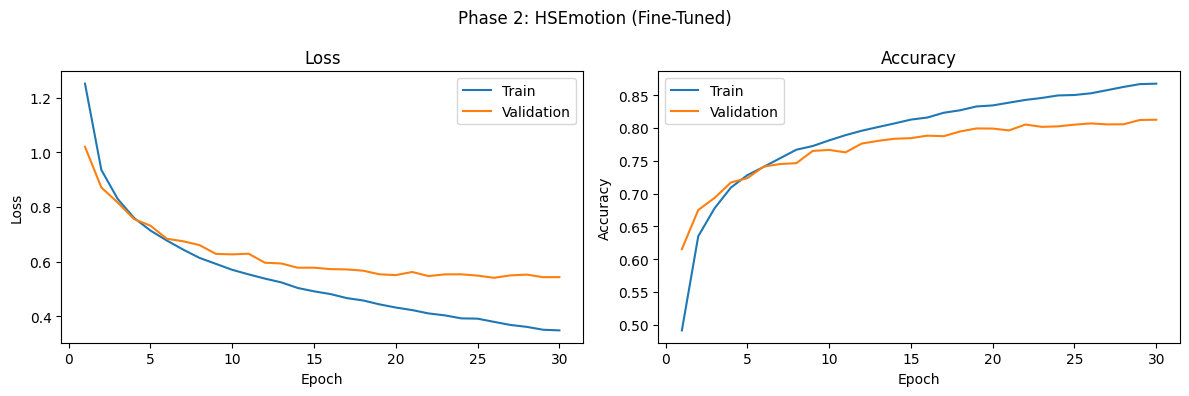

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/phase2_finetuned/training_history.png


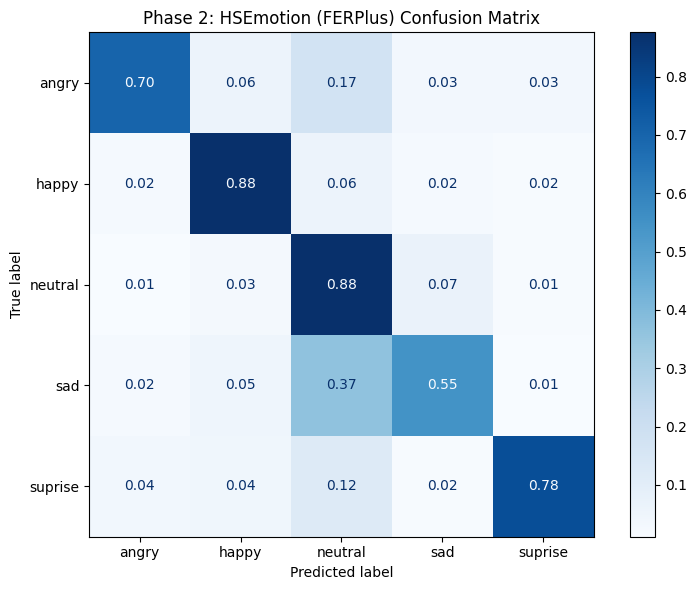

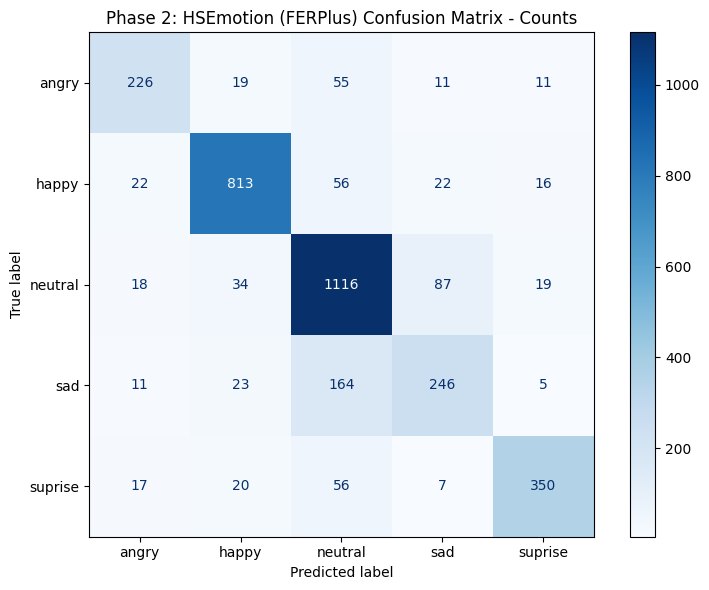

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/phase2_finetuned/confusion_matrix.png
Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/phase2_finetuned/confusion_matrix_counts.png


In [21]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    plot_training_history(
        history_p2,
        "Phase 2: HSEmotion (Fine-Tuned)",
        P2_DIR / "training_history.png",
    )

    plot_confusion_matrices(
        y_true_p2, y_pred_p2, CLASS_NAMES,
        "Phase 2: HSEmotion (FERPlus)", P2_DIR,
    )

In [22]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    save_outputs(
        history=history_p2,
        y_true=y_true_p2,
        y_pred=y_pred_p2,
        class_names=CLASS_NAMES,
        model_name="hsemotion_phase2_finetuned",
        best_val_acc=best_val_acc_p2,
        extra_info={
            "phase": "phase2_partial_finetune",
            "model_class": "models.hsemotion_model.HSEmotion",
            "pretraining": (
                "AffectNet" if AFFECTNET_LOADED
                else "ImageNet"
            ),
            "backbone_lr": PHASE2_BACKBONE_LR,
            "classifier_lr": PHASE2_CLASSIFIER_LR,
            "unfreeze_last_n": PHASE2_UNFREEZE_LAST_N,
            "classifier_head": f"1280 -> 256 -> {NUM_CLASSES}",
            "trainable_params": sum(
                p.numel() for p in model_p2.parameters()
                if p.requires_grad
            ),
        },
        save_dir=P2_DIR,
    )

All outputs saved to: /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/phase2_finetuned
--------------------------------------------------
  best_model.pth                            17236.2 KB
  confusion_matrix.png                         69.4 KB
  confusion_matrix_counts.png                  61.8 KB
  evaluation_summary.json                       1.7 KB
  training_history.json                         2.9 KB
  training_history.png                         75.7 KB


---

## 7. Final Comparison and Best Model Selection

In [23]:
# Select the best model across phases and save it as
# the canonical checkpoint.
print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)
print(
    f"  Phase 1 (frozen):     "
    f"val {best_val_acc_p1:.2%} | test {test_acc_p1:.2%}"
)

if run_phase2:
    print(
        f"  Phase 2 (fine-tuned): "
        f"val {best_val_acc_p2:.2%} | test {test_acc_p2:.2%}"
    )
    improvement = test_acc_p2 - test_acc_p1
    print(
        f"  Improvement:          "
        f"{improvement:+.2%} test accuracy"
    )
    print()

    if test_acc_p2 > test_acc_p1:
        best_source = P2_DIR / "best_model.pth"
        best_phase = "Phase 2 (fine-tuned)"
    else:
        best_source = P1_DIR / "best_model.pth"
        best_phase = "Phase 1 (frozen)"
else:
    best_source = P1_DIR / "best_model.pth"
    best_phase = "Phase 1 (frozen)"

# Copy the best checkpoint to the canonical location
canonical_path = OUTPUT_DIR / "best_hsemotion.pth"
shutil.copy2(best_source, canonical_path)

print(f"Best model: {best_phase}")
print(f"Saved to:   {canonical_path}")

# Copy all outputs to Google Drive
copy_to_drive(OUTPUT_DIR, DRIVE_OUTPUT_DIR)

FINAL COMPARISON
  Phase 1 (frozen):     val 57.37% | test 55.78%
  Phase 2 (fine-tuned): val 81.26% | test 80.34%
  Improvement:          +24.56% test accuracy

Best model: Phase 2 (fine-tuned)
Saved to:   /content/adaptive-emotion-aware-virtual-interaction-system/results/hsemotion/best_hsemotion.pth
Copied outputs to Drive: /content/drive/MyDrive/emotion_project/results/hsemotion


## Summary

**Outputs saved to `results/hsemotion/`:**

| File | Description |
|------|-------------|
| `best_hsemotion.pth` | Best model checkpoint (by test accuracy) |
| `phase1_frozen/` | Phase 1 outputs: checkpoint, history, plots |
| `phase2_finetuned/` | Phase 2 outputs: checkpoint, history, plots |

**Each phase directory contains:**

| File | Description |
|------|-------------|
| `best_model.pth` | Phase-specific best checkpoint |
| `training_history.json` | Per-epoch train/val loss and accuracy |
| `training_history.png` | Loss and accuracy curves |
| `evaluation_summary.json` | Test accuracy and per-class report |
| `confusion_matrix.png` | Normalized confusion matrix |
| `confusion_matrix_counts.png` | Raw count confusion matrix |

**Key difference from other models:**

HSEmotion uses AffectNet-pretrained weights (emotion-domain features)
instead of ImageNet pretraining (generic visual features). This typically
provides better baseline accuracy in Phase 1, and the fine-tuned model
in Phase 2 starts from a stronger initialization.